# COVID-19 Global Data Analysis

## Project Overview

This project analyzes global COVID-19 data published by the World Health Organization (WHO).

The objective is to understand:

- Global COVID-19 case trends
- Global death trends
- Country-wise case distribution
- Country-wise death distribution
- Regional differences
- Monthly and yearly trends
- COVID-19 trends in India
- Relationship between cases and deaths
- Countries with the highest reported cases and deaths

## Tools & Technologies

- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Dataset

WHO COVID-19 Global Daily Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

df = pd.read_csv("WHO-COVID-19-global-daily-data.csv")

df.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-04,AF,Afghanistan,EMR,NaN,0,NaN,0
1,2020-01-04,DZ,Algeria,AFR,NaN,0,NaN,0
2,2020-01-04,AL,Albania,EUR,NaN,0,NaN,0
3,2020-01-04,AI,Anguilla,AMR,NaN,0,NaN,0
4,2020-01-04,AS,American Samoa,WPR,0.0,0,0.0,0


In [2]:
df.shape

(583440, 8)

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 583440
Number of columns: 8


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 583440 entries, 0 to 583439
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Date_reported      583440 non-null  str    
 1   Country_code       581009 non-null  str    
 2   Country            583440 non-null  str    
 3   WHO_region         583440 non-null  str    
 4   New_cases          215026 non-null  float64
 5   Cumulative_cases   583440 non-null  int64  
 6   New_deaths         156336 non-null  float64
 7   Cumulative_deaths  583440 non-null  int64  
dtypes: float64(2), int64(2), str(4)
memory usage: 35.6 MB


In [5]:
df.describe()

,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
count,2.150260e+05,5.834400e+05,156336.000000,5.834400e+05
mean,3.624523e+03,2.238351e+06,45.520891,2.295842e+04
std,4.803578e+04,9.035838e+06,240.623748,9.056134e+04
min,-6.507900e+04,0.000000e+00,-3520.000000,0.000000e+00
25%,2.000000e+00,8.001750e+03,0.000000,5.300000e+01
50%,5.700000e+01,6.825700e+04,2.000000,8.350000e+02
75%,6.490000e+02,7.150838e+05,14.000000,8.761000e+03
max,6.966046e+06,1.034368e+08,44047.000000,1.239049e+06


In [6]:
df.describe(include = "all")

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
count,583440,581009,583440,583440,2.150260e+05,5.834400e+05,156336.000000,5.834400e+05
unique,2431,239,240,7,NaN,NaN,NaN,NaN
top,2020-01-04,AF,Afghanistan,EUR,NaN,NaN,NaN,NaN
freq,240,2431,2431,150722,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,3.624523e+03,2.238351e+06,45.520891,2.295842e+04
std,NaN,NaN,NaN,NaN,4.803578e+04,9.035838e+06,240.623748,9.056134e+04
min,NaN,NaN,NaN,NaN,-6.507900e+04,0.000000e+00,-3520.000000,0.000000e+00
25%,NaN,NaN,NaN,NaN,2.000000e+00,8.001750e+03,0.000000,5.300000e+01
50%,NaN,NaN,NaN,NaN,5.700000e+01,6.825700e+04,2.000000,8.350000e+02
75%,NaN,NaN,NaN,NaN,6.490000e+02,7.150838e+05,14.000000,8.761000e+03


In [7]:
df.columns

Index(['Date_reported', 'Country_code', 'Country', 'WHO_region', 'New_cases',
       'Cumulative_cases', 'New_deaths', 'Cumulative_deaths'],
      dtype='str')

In [8]:
df.isnull().sum()

Date_reported             0
Country_code           2431
Country                   0
WHO_region                0
New_cases            368414
Cumulative_cases          0
New_deaths           427104
Cumulative_deaths         0
dtype: int64

In [9]:
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending = False)
missing_percentage

New_deaths           73.204443
New_cases            63.145139
Country_code          0.416667
Date_reported         0.000000
WHO_region            0.000000
Country               0.000000
Cumulative_cases      0.000000
Cumulative_deaths     0.000000
dtype: float64

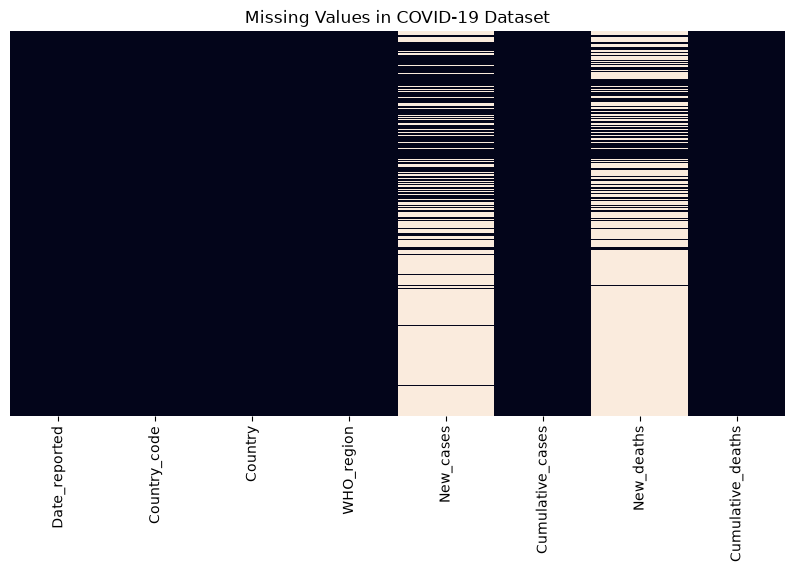

In [10]:
plt.figure(figsize = (10,5))
sns.heatmap(
    df.isnull(),
    cbar = False,
    yticklabels = False
)

plt.title("Missing Values in COVID-19 Dataset")
plt.show()

In [12]:
df["Date_reported"] = pd.to_datetime(df["Date_reported"])

In [13]:
df["Date_reported"].dtype

dtype('<M8[us]')

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df[df.duplicated()]

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths


In [18]:
df = df.drop_duplicates()

In [19]:
df["Country"].nunique()

240

In [20]:
df["Country"].unique()

<StringArray>
[                       'Afghanistan',                            'Algeria',
                            'Albania',                           'Anguilla',
                     'American Samoa',                            'Armenia',
                'Antigua and Barbuda',                         'Azerbaijan',
                            'Andorra',                            'Austria',
 ...
                         'Uzbekistan',                           'Thailand',
                            'Vanuatu',                            'Tokelau',
                  'Wallis and Futuna',               'United Arab Emirates',
                             'Zambia',        'United Republic of Tanzania',
       'United States Virgin Islands', 'Venezuela (Bolivarian Republic of)']
Length: 240, dtype: str

In [22]:
df["WHO_region"].value_counts()

WHO_region
EUR      150722
AMR      131274
AFR      121550
WPR       87516
EMR       53482
SEAR      24310
OTHER     14586
Name: count, dtype: int64

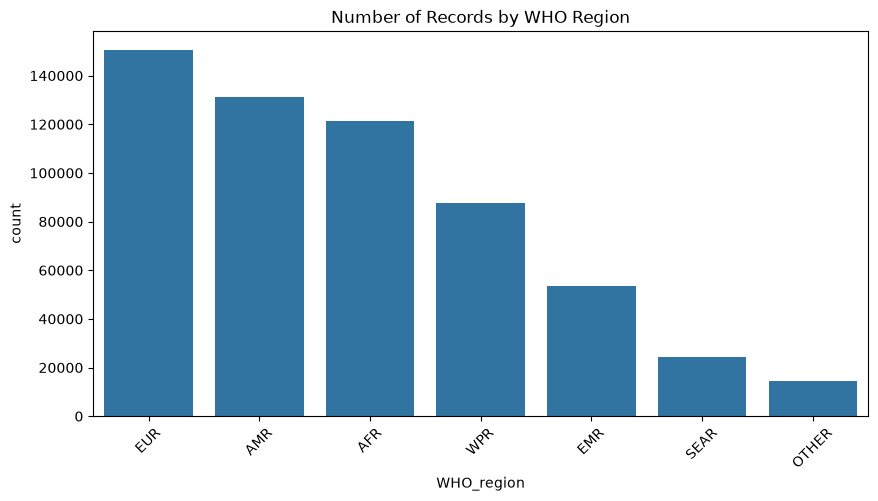

In [25]:
plt.figure(figsize = (10, 5))
sns.countplot(
    data = df,
    x = "WHO_region",
    order = df["WHO_region"].value_counts().index
)

plt.title("Number of Records by WHO Region")
plt.xticks(rotation = 45)
plt.show()

In [26]:
covid = df.copy()

In [27]:
covid[
    [
        "New_cases",
        "Cumulative_cases",
        "New_deaths",
        "Cumulative_deaths"
    ]
    ].isnull().sum()

New_cases            368414
Cumulative_cases          0
New_deaths           427104
Cumulative_deaths         0
dtype: int64

In [28]:
covid["New_cases"] = covid["New_cases"].fillna(0)
covid["New_deaths"] = covid["New_deaths"].fillna(0)

In [29]:
covid["Cumulative_cases"] = covid["Cumulative_cases"].fillna(0)
covid["Cumulative_deaths"] = covid["Cumulative_deaths"].fillna(0)

In [30]:
covid["Year"] = covid["Date_reported"].dt.year
covid["Month"] = covid["Date_reported"].dt.month
covid["Month_Name"] = covid["Date_reported"].dt.month_name()

In [31]:
covid["Year_Month"] = covid["Date_reported"].dt.to_period("M")
covid.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths,Year,Month,Month_Name,Year_Month
0,2020-01-04,AF,Afghanistan,EMR,0.0,0,0.0,0,2020,1,January,2020-01
1,2020-01-04,DZ,Algeria,AFR,0.0,0,0.0,0,2020,1,January,2020-01
2,2020-01-04,AL,Albania,EUR,0.0,0,0.0,0,2020,1,January,2020-01
3,2020-01-04,AI,Anguilla,AMR,0.0,0,0.0,0,2020,1,January,2020-01
4,2020-01-04,AS,American Samoa,WPR,0.0,0,0.0,0,2020,1,January,2020-01


In [32]:
total_cases = covid["New_cases"].sum()
print("Total reported cases: ", total_cases)

Total reported cases:  779366737.0


In [33]:
total_deaths = covid["New_deaths"].sum()
print("Total reported deaths: ", total_deaths)

Total reported deaths:  7116554.0


In [35]:
daily_global = covid.groupby(
    "Date_reported"
).agg(
    New_cases = ("New_cases", "sum"),
    New_deaths = ("New_deaths", "sum")
).reset_index()

daily_global.head()

,Date_reported,New_cases,New_deaths
0,2020-01-04,3.0,0.0
1,2020-01-05,-1.0,3.0
2,2020-01-06,3.0,0.0
3,2020-01-07,0.0,0.0
4,2020-01-08,1.0,0.0


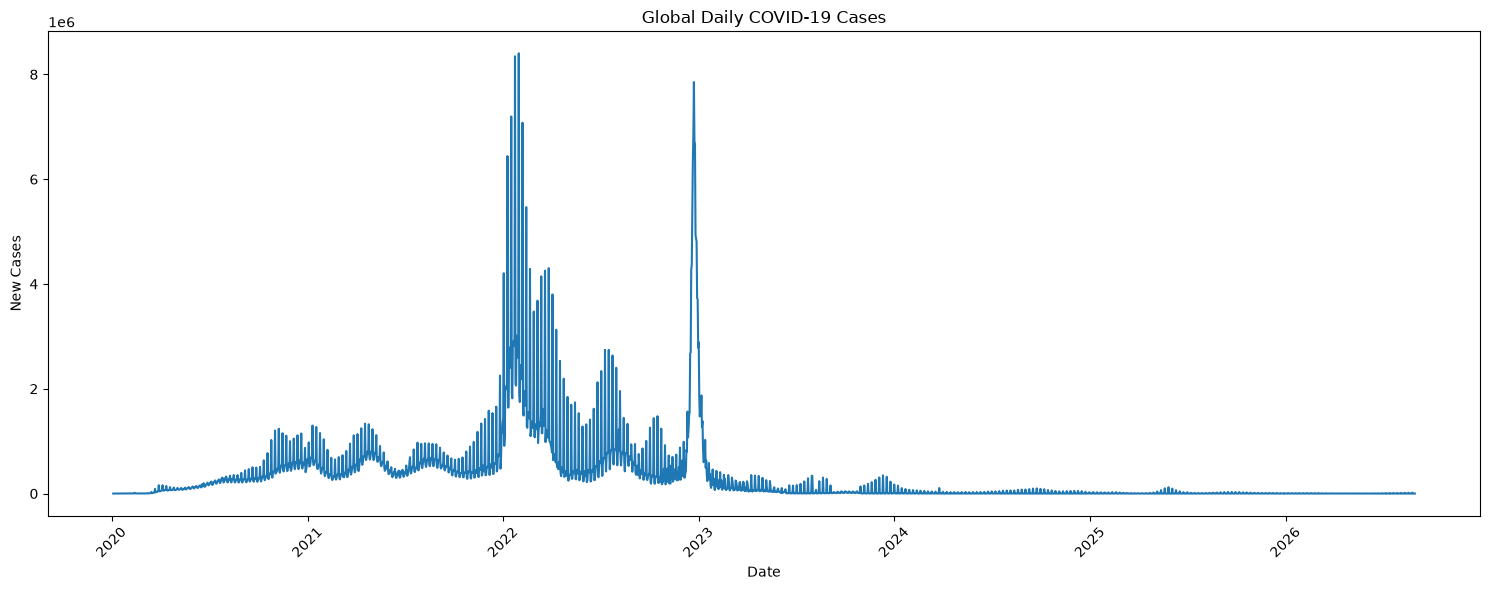

In [36]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_global["Date_reported"],
    daily_global["New_cases"]
)

plt.title("Global Daily COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

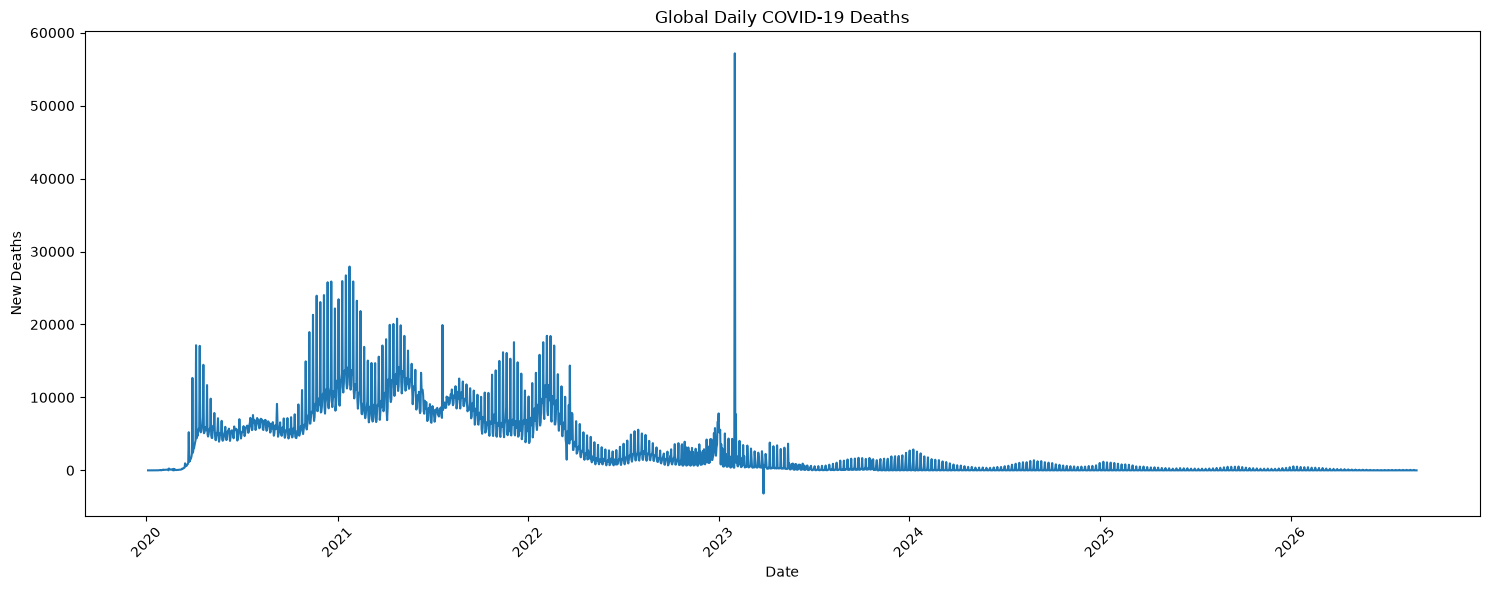

In [37]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_global["Date_reported"],
    daily_global["New_deaths"]
)

plt.title("Global Daily COVID-19 Deaths")
plt.xlabel("Date")
plt.ylabel("New Deaths")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [40]:
monthly_global = covid.groupby(
    "Year_Month"
).agg(
    New_cases = ("New_cases", "sum"),
    New_deaths = ("New_deaths", "sum")
).reset_index()

In [41]:
monthly_global["Year_Month"] = (
    monthly_global["Year_Month"].dt.to_timestamp()
)

In [42]:
monthly_global.head()

,Year_Month,New_cases,New_deaths
0,2020-01-01,9822.0,219.0
1,2020-02-01,75373.0,2717.0
2,2020-03-01,697579.0,40666.0
3,2020-04-01,2222868.0,193544.0
4,2020-05-01,2886397.0,164357.0


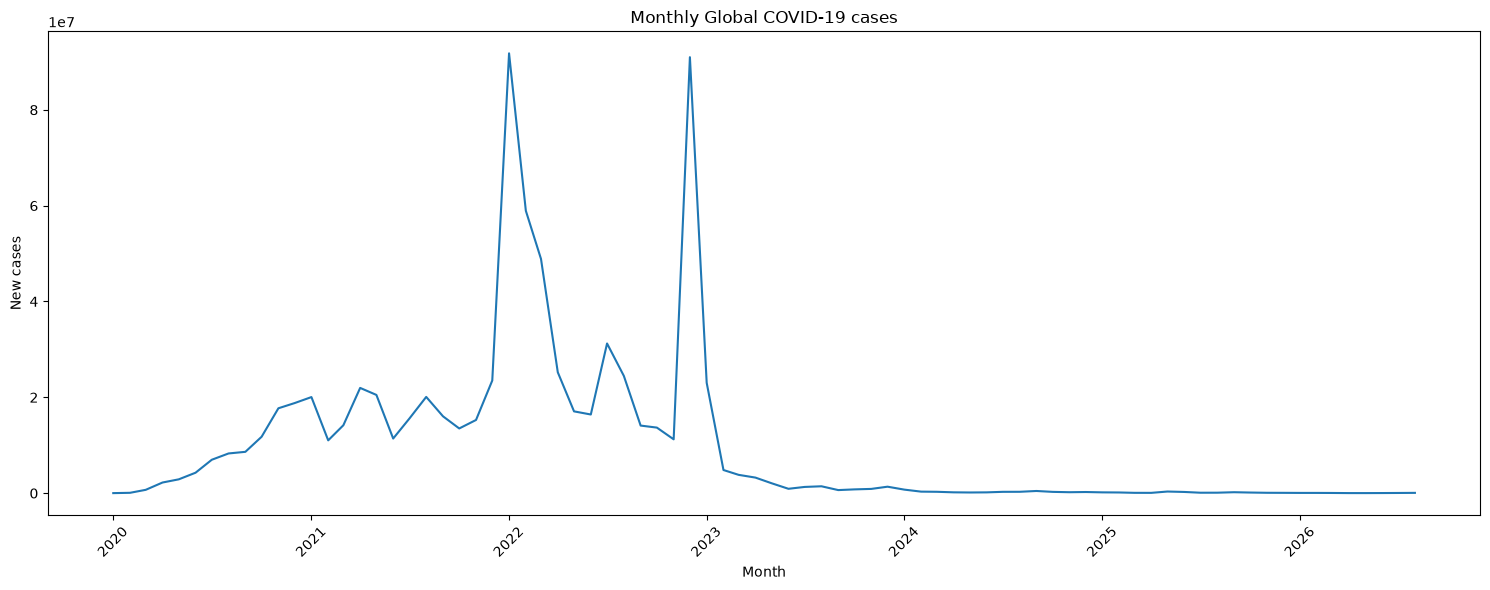

In [45]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_global["Year_Month"],
    monthly_global["New_cases"]
)

plt.title("Monthly Global COVID-19 cases")
plt.xlabel("Month")
plt.ylabel("New cases")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

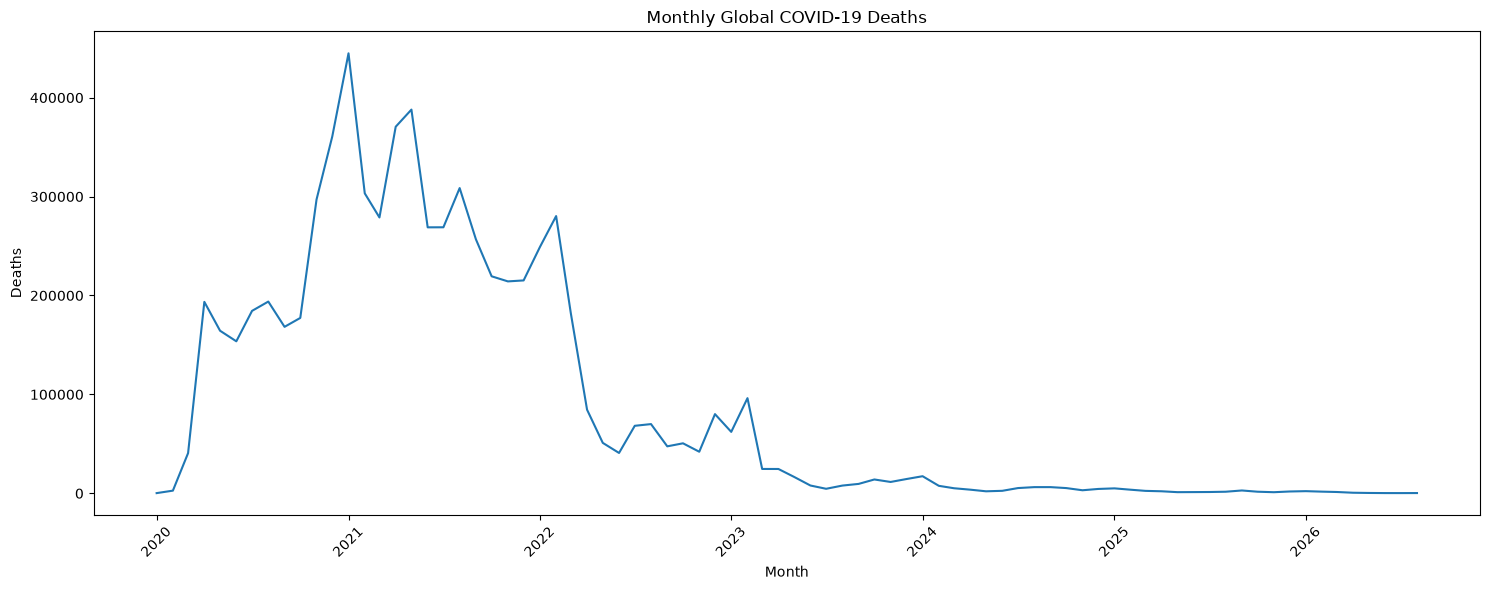

In [46]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_global["Year_Month"],
    monthly_global["New_deaths"]
)

plt.title("Monthly Global COVID-19 Deaths")
plt.xlabel("Month")
plt.ylabel("Deaths")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [48]:
highest_case_month = monthly_global.loc[
    monthly_global["New_cases"].idxmax()
    ]
highest_case_month

Year_Month    2022-01-01 00:00:00
New_cases              91789126.0
New_deaths               248905.0
Name: 24, dtype: object

In [49]:
print(
    "Highest reported case month:", highest_case_month["Year_Month"]
)
print(
    "Reported cases:", highest_case_month["New_cases"]
)

Highest reported case month: 2022-01-01 00:00:00
Reported cases: 91789126.0


In [50]:
highest_death_month = monthly_global.loc[
    monthly_global["New_deaths"].idxmax()
    ]
print(
    "Highest reported death month:", highest_case_month["Year_Month"]
)
print(
    "Reported deaths:", highest_death_month["New_deaths"]
)

Highest reported death month: 2022-01-01 00:00:00
Reported deaths: 444781.0


In [58]:
country_summary = covid.groupby(
    "Country"
).agg(
    Total_Cases = ("New_cases", "sum"),
    Total_Deaths = ("New_deaths", "sum")
).reset_index()

In [52]:
country_summary.head()

,Country,New_cases,New_deaths
0,Afghanistan,235214.0,7998.0
1,Albania,337234.0,3608.0
2,Algeria,272440.0,6881.0
3,American Samoa,8359.0,34.0
4,Andorra,48015.0,159.0


In [59]:
top_10_cases = country_summary.sort_values(
    "Total_Cases",
    ascending=False
).head(10)

top_10_cases

,Country,Total_Cases,Total_Deaths
229,United States of America,103436829.0,1239049.0
42,China,99381761.0,122398.0
96,India,45056221.0,533849.0
72,France,39061500.0,168207.0
78,Germany,38437953.0,174979.0
28,Brazil,38050567.0,704066.0
175,Republic of Korea,34571873.0,35934.0
111,Japan,33803572.0,74694.0
109,Italy,26969918.0,198523.0
226,United Kingdom of Great Britain and Northern I...,25122084.0,232112.0


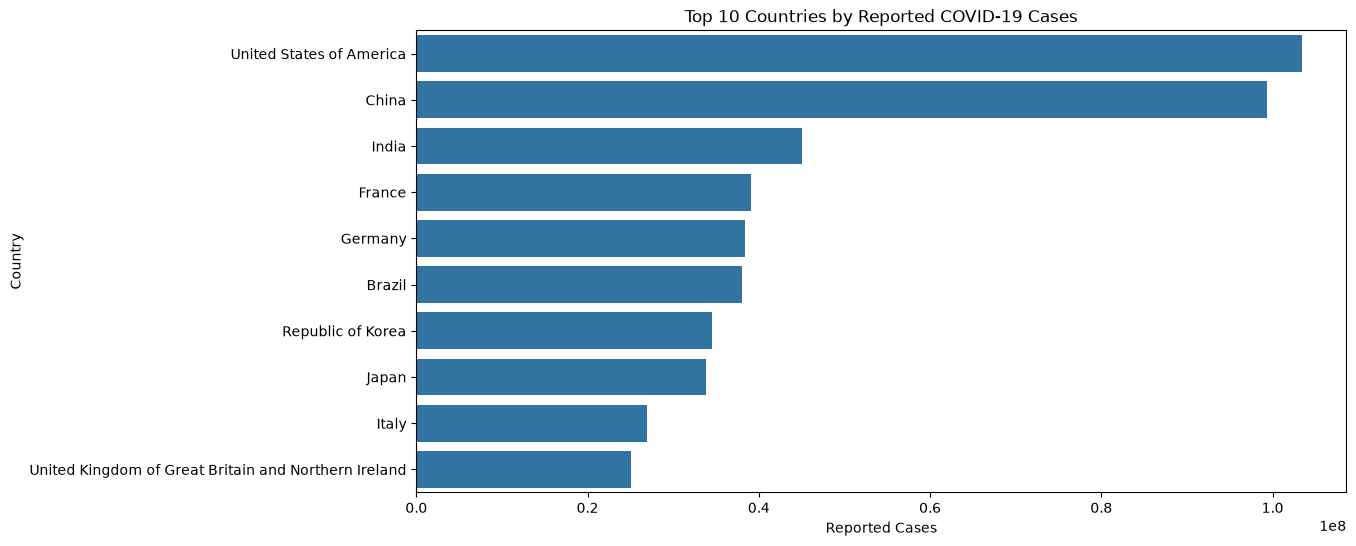

In [60]:
plt.figure(figsize=(12,6))

sns.barplot(
    data = top_10_cases,
    x = "Total_Cases",
    y = "Country"
)

plt.title("Top 10 Countries by Reported COVID-19 Cases")
plt.xlabel("Reported Cases")
plt.ylabel("Country")
plt.show()

In [61]:
top_10_deaths= country_summary.sort_values(
    "Total_Deaths",
    ascending=False
).head(10)

top_10_deaths

,Country,Total_Cases,Total_Deaths
229,United States of America,103436829.0,1239049.0
28,Brazil,38050567.0,704066.0
96,India,45056221.0,533849.0
178,Russian Federation,24901467.0,404290.0
140,Mexico,7632101.0,335153.0
226,United Kingdom of Great Britain and Northern I...,25122084.0,232112.0
168,Peru,4533862.0,221072.0
109,Italy,26969918.0,198523.0
78,Germany,38437953.0,174979.0
72,France,39061500.0,168207.0


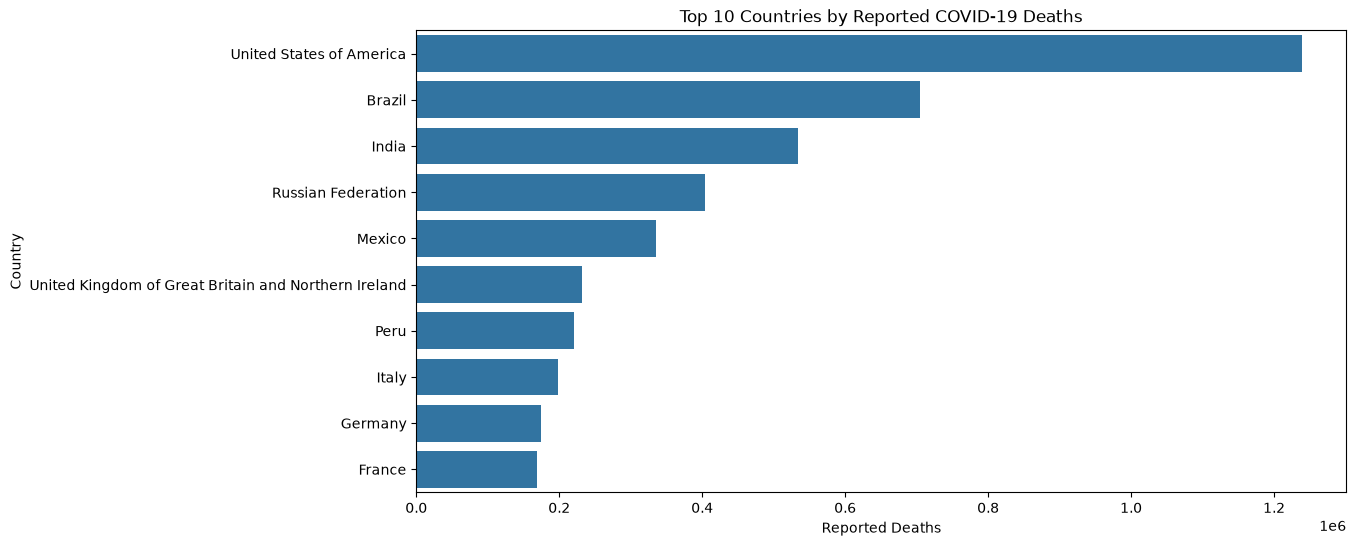

In [62]:
plt.figure(figsize=(12,6))

sns.barplot(
    data = top_10_deaths,
    x = "Total_Deaths",
    y = "Country"
)

plt.title("Top 10 Countries by Reported COVID-19 Deaths")
plt.xlabel("Reported Deaths")
plt.ylabel("Country")
plt.show()

In [63]:
region_summary = covid.groupby(
    "WHO_region"
).agg(
    Total_Cases = ("New_cases", "sum"),
    Total_Deaths = ("New_deaths", "sum")
).reset_index()
region_summary

,WHO_region,Total_Cases,Total_Deaths
0,AFR,9590195.0,175532.0
1,AMR,193917141.0,3074523.0
2,EMR,23417911.0,351975.0
3,EUR,281769988.0,2283461.0
4,OTHER,764.0,13.0
5,SEAR,55229678.0,647305.0
6,WPR,215441060.0,583745.0


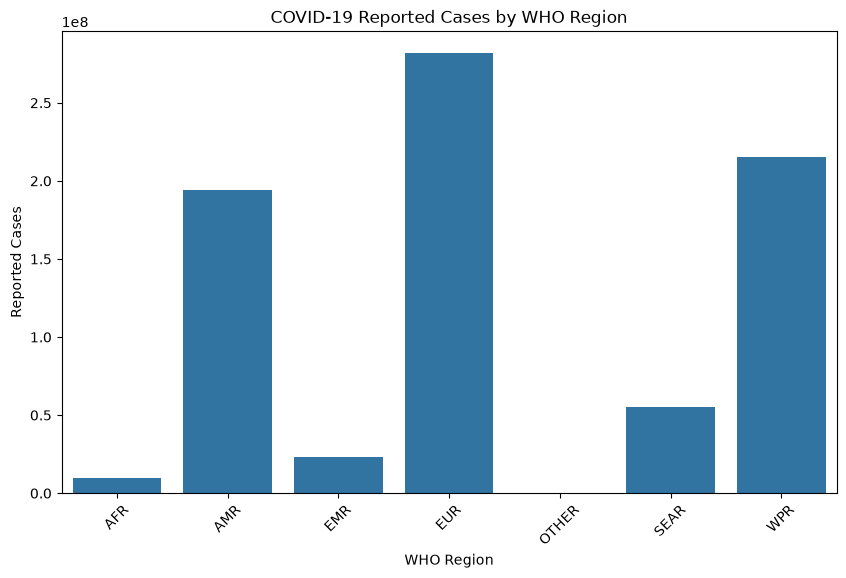

In [65]:
plt.figure(figsize=(10,6))

sns.barplot(
    data = region_summary,
    x = "WHO_region",
    y = "Total_Cases"
)

plt.title("COVID-19 Reported Cases by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Reported Cases")
plt.xticks(rotation = 45)

plt.show()

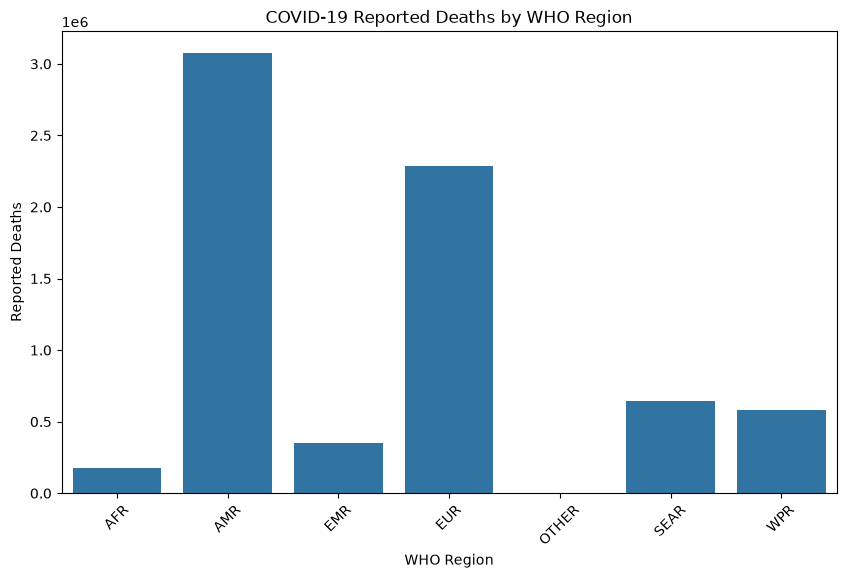

In [66]:
plt.figure(figsize=(10,6))

sns.barplot(
    data = region_summary,
    x = "WHO_region",
    y = "Total_Deaths"
)

plt.title("COVID-19 Reported Deaths by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Reported Deaths")
plt.xticks(rotation = 45)

plt.show()

In [67]:
india = covid[
    covid["Country"].str.lower() == "india"
    ].copy()
india.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths,Year,Month,Month_Name,Year_Month
111,2020-01-04,IN,India,SEAR,0.0,0,0.0,0,2020,1,January,2020-01
423,2020-01-05,IN,India,SEAR,0.0,0,0.0,0,2020,1,January,2020-01
591,2020-01-06,IN,India,SEAR,0.0,0,0.0,0,2020,1,January,2020-01
903,2020-01-07,IN,India,SEAR,0.0,0,0.0,0,2020,1,January,2020-01
1071,2020-01-08,IN,India,SEAR,0.0,0,0.0,0,2020,1,January,2020-01


In [69]:
india.shape

(2431, 12)

In [70]:
india_total_cases = india["New_cases"].sum()
india_total_deaths = india["New_deaths"].sum()
print("India reported cases: ", india_total_cases)
print("India reported deaths: ", india_total_deaths)

India reported cases:  45056221.0
India reported deaths:  533849.0


In [71]:
india_monthly = india.groupby(
    "Year_Month"
).agg(
    New_cases = ("New_cases", "sum"),
    New_deaths = ("New_deaths", "sum")
).reset_index()

india_monthly["Year_Month"] = (
    india_monthly["Year_Month"].dt.to_timestamp()
)

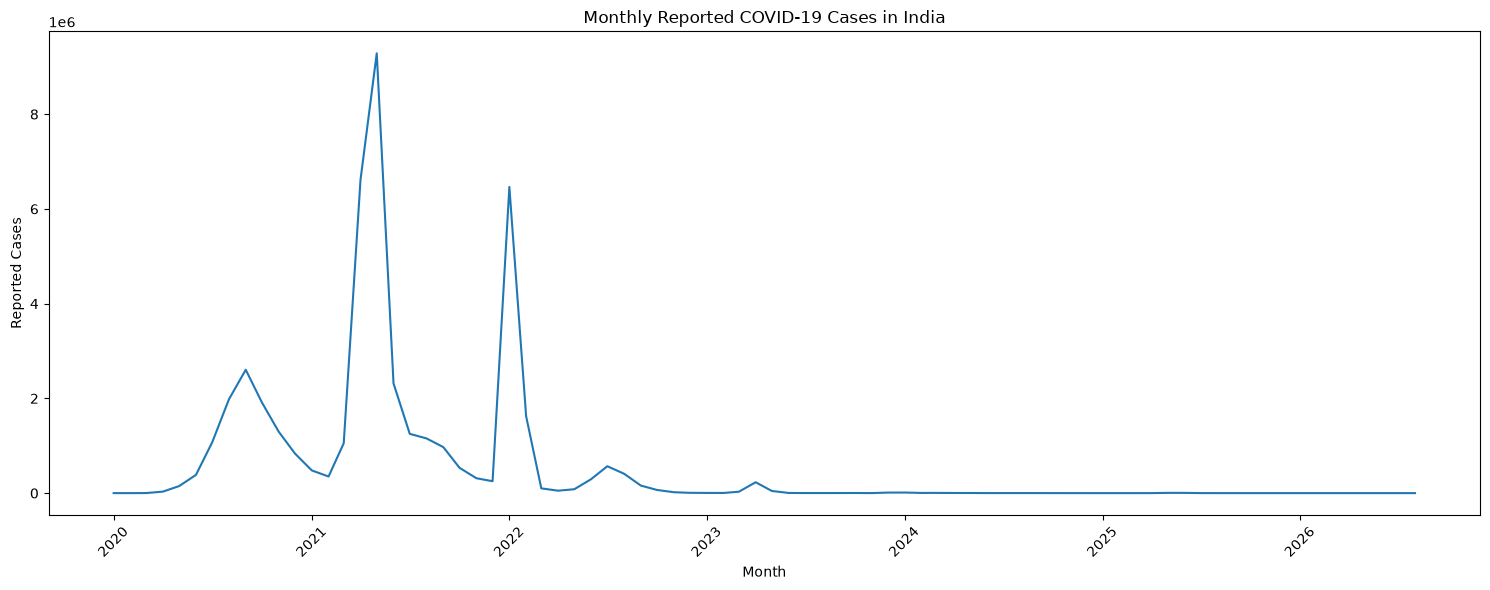

In [72]:
plt.figure(figsize=(15,6))

plt.plot(
    india_monthly["Year_Month"],
    india_monthly["New_cases"]
)

plt.title("Monthly Reported COVID-19 Cases in India")
plt.xlabel("Month")
plt.ylabel("Reported Cases")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

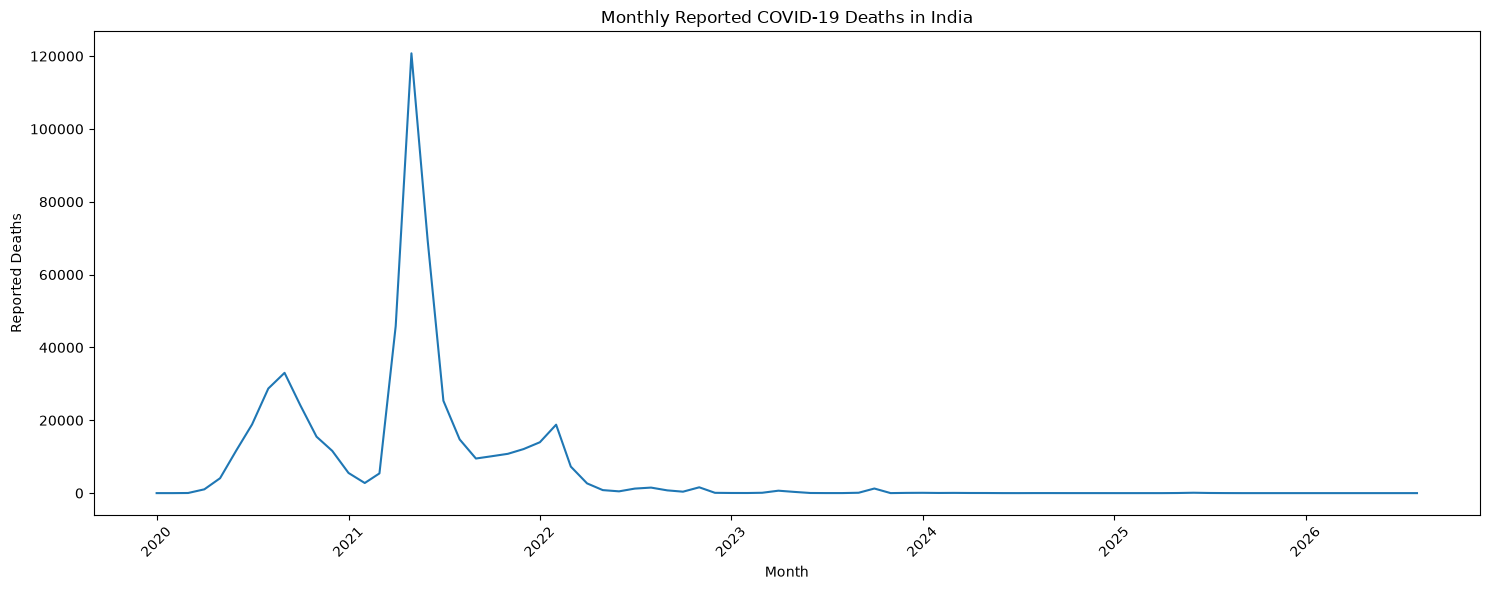

In [74]:
plt.figure(figsize=(15,6))

plt.plot(
    india_monthly["Year_Month"],
    india_monthly["New_deaths"]
)

plt.title("Monthly Reported COVID-19 Deaths in India")
plt.xlabel("Month")
plt.ylabel("Reported Deaths")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [75]:
yearly_summary = covid.groupby(
    "Year"
).agg(
    Total_Cases = ("New_cases", "sum"),
    Total_Deaths = ("New_deaths", "sum")
).reset_index()
yearly_summary

,Year,Total_Cases,Total_Deaths
0,2020,82335574.0,1936752.0
1,2021,203111242.0,3537358.0
2,2022,444029532.0,1246156.0
3,2023,44322098.0,294000.0
4,2024,3558323.0,69075.0
5,2025,1704345.0,26186.0
6,2026,305623.0,7027.0


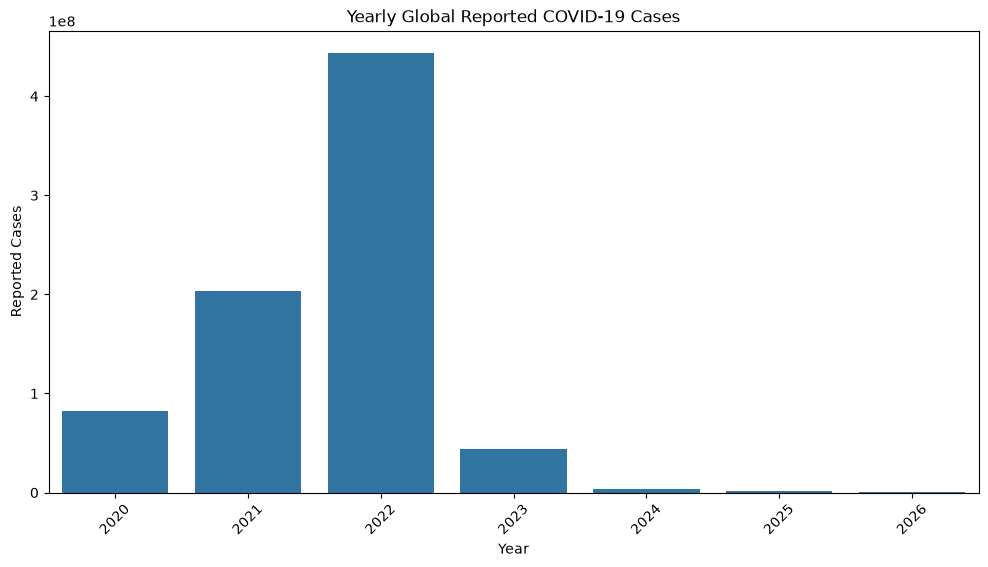

In [76]:
plt.figure(figsize=(12,6))

sns.barplot(
    data = yearly_summary,
    x = "Year",
    y = "Total_Cases"
)

plt.title("Yearly Global Reported COVID-19 Cases")
plt.xlabel("Year")
plt.ylabel("Reported Cases")
plt.xticks(rotation = 45)

plt.show()

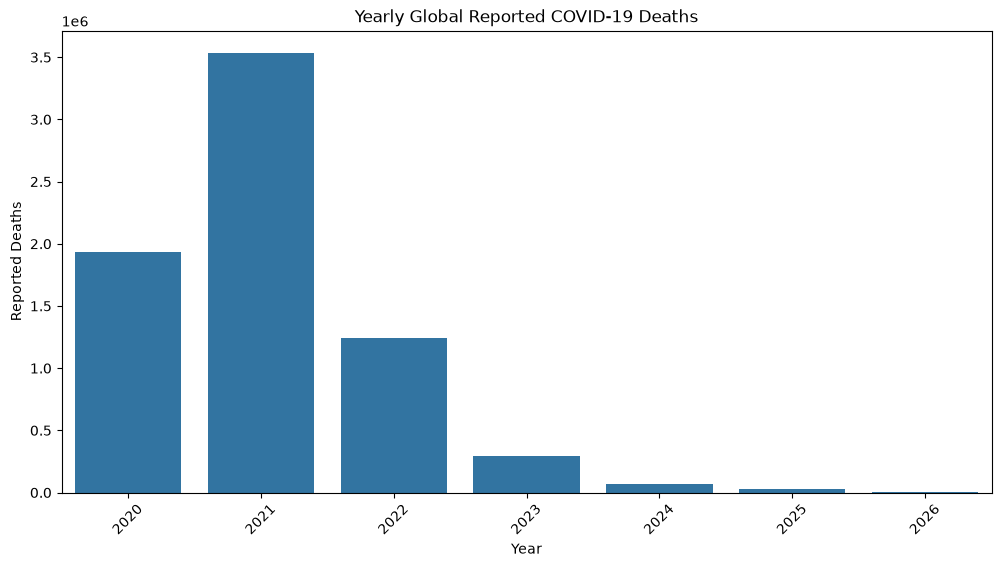

In [77]:
plt.figure(figsize=(12,6))

sns.barplot(
    data = yearly_summary,
    x = "Year",
    y = "Total_Deaths"
)

plt.title("Yearly Global Reported COVID-19 Deaths")
plt.xlabel("Year")
plt.ylabel("Reported Deaths")
plt.xticks(rotation = 45)

plt.show()

In [78]:
total_cases = covid["New_cases"].sum()
total_deaths = covid["New_deaths"].sum()

cfr = (total_deaths / total_cases) * 100
print("Reported Case Fatality Ratio:", cfr, "%")

Reported Case Fatality Ratio: 0.9131200578810434 %


In [80]:
country_summary["CFR"] = (
    country_summary["Total_Deaths"] /
    country_summary["Total_Cases"]
) * 100

In [81]:
country_summary.sort_values(
    "CFR",
    ascending = False
).head(10)

,Country,Total_Cases,Total_Deaths,CFR
236,Yemen,11945.0,2159.0,18.074508
206,Sudan,63993.0,5046.0,7.885237
210,Syrian Arab Republic,57423.0,3163.0,5.508246
201,Somalia,27334.0,1361.0,4.979147
168,Peru,4533862.0,221072.0,4.876020
61,Egypt,516023.0,24830.0,4.811801
140,Mexico,7632101.0,335153.0,4.391360
26,Bosnia and Herzegovina,404289.0,16419.0,4.061204
124,Liberia,7932.0,294.0,3.706505
0,Afghanistan,235214.0,7998.0,3.400308


In [82]:
country_cfr = country_summary[
    country_summary["Total_Cases"] >= 100000
    ].copy()

In [83]:
country_cfr.sort_values(
    "CFR",
    ascending = False
).head(10)

,Country,Total_Cases,Total_Deaths,CFR
168,Peru,4533862.0,221072.0,4.876020
61,Egypt,516023.0,24830.0,4.811801
140,Mexico,7632101.0,335153.0,4.391360
26,Bosnia and Herzegovina,404289.0,16419.0,4.061204
0,Afghanistan,235214.0,7998.0,3.400308
60,Ecuador,1082356.0,36064.0,3.331991
148,Myanmar,643401.0,19494.0,3.029837
31,Bulgaria,1341082.0,38778.0,2.891546
159,North Macedonia,352093.0,9991.0,2.837603
167,Paraguay,735759.0,19880.0,2.701972


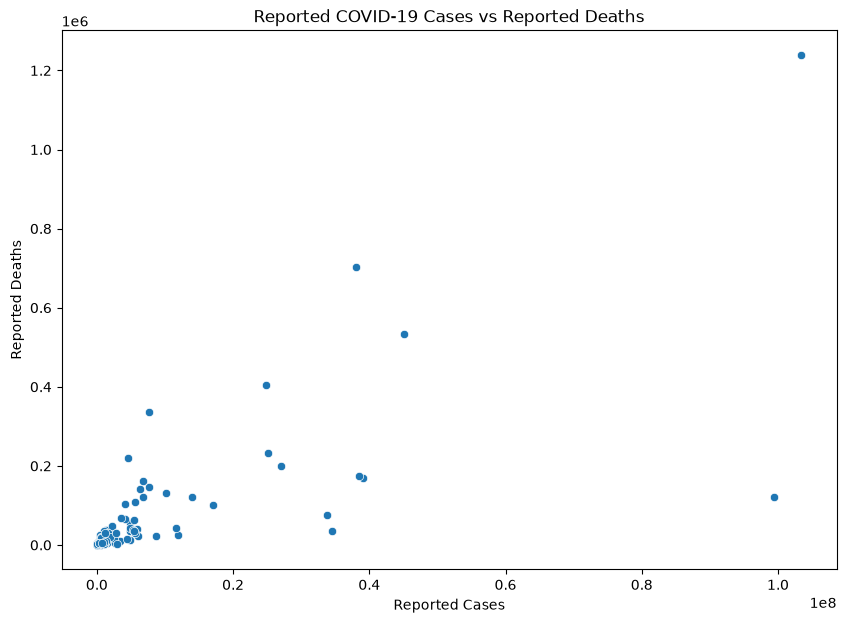

In [84]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data = country_summary,
    x = "Total_Cases",
    y = "Total_Deaths"
)

plt.title("Reported COVID-19 Cases vs Reported Deaths")
plt.xlabel("Reported Cases")
plt.ylabel("Reported Deaths")

plt.show()

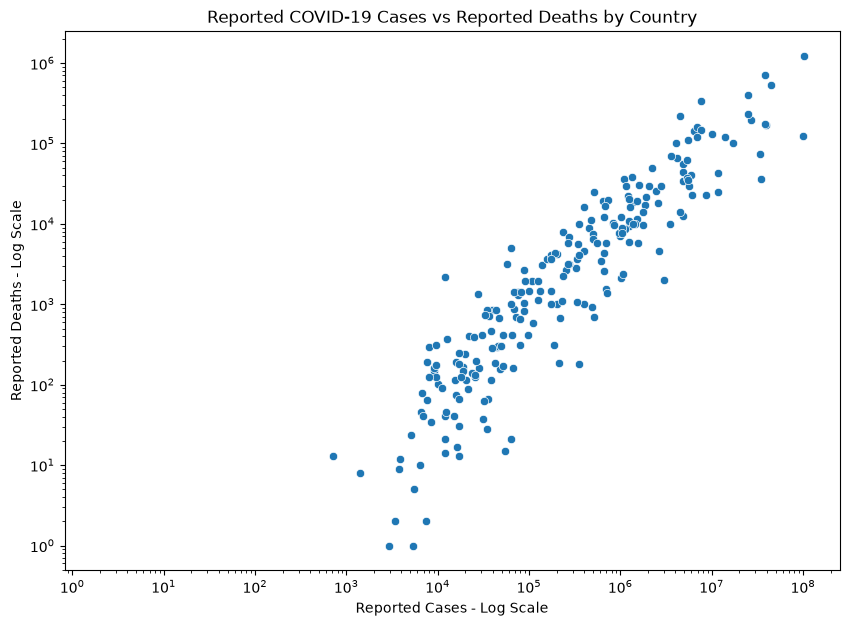

In [85]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data = country_summary,
    x = "Total_Cases",
    y = "Total_Deaths"
)

plt.xscale("log")
plt.yscale("log")

plt.title("Reported COVID-19 Cases vs Reported Deaths by Country")
plt.xlabel("Reported Cases - Log Scale")
plt.ylabel("Reported Deaths - Log Scale")

plt.show()

In [86]:
correlation = country_summary[
    ["Total_Cases", "Total_Deaths"]
    ].corr()
correlation

,Total_Cases,Total_Deaths
Total_Cases,1.000000,0.767556
Total_Deaths,0.767556,1.000000


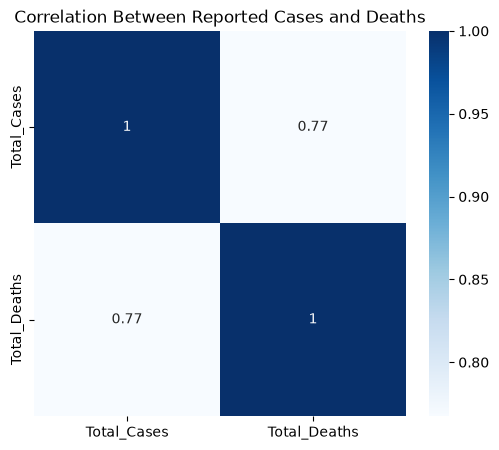

In [87]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Between Reported Cases and Deaths")

plt.show()

In [88]:
peak_case_day = daily_global.loc[
    daily_global["New_cases"].idxmax()
]

peak_case_day

Date_reported    2022-01-30 00:00:00
New_cases                  8401963.0
New_deaths                   17569.0
Name: 757, dtype: object

In [89]:
print("Peak reported case date:")
print(peak_case_day["Date_reported"])

print("Reported cases:")
print(peak_case_day["New_cases"])

Peak reported case date:
2022-01-30 00:00:00
Reported cases:
8401963.0


In [90]:
peak_death_day = daily_global.loc[
    daily_global["New_deaths"].idxmax()
]

peak_death_day

Date_reported    2023-02-01 00:00:00
New_cases                   176142.0
New_deaths                   57167.0
Name: 1124, dtype: object

In [91]:
daily_global["Cases_7_Day_Average"] = (
    daily_global["New_cases"]
    .rolling(window=7)
    .mean()
)

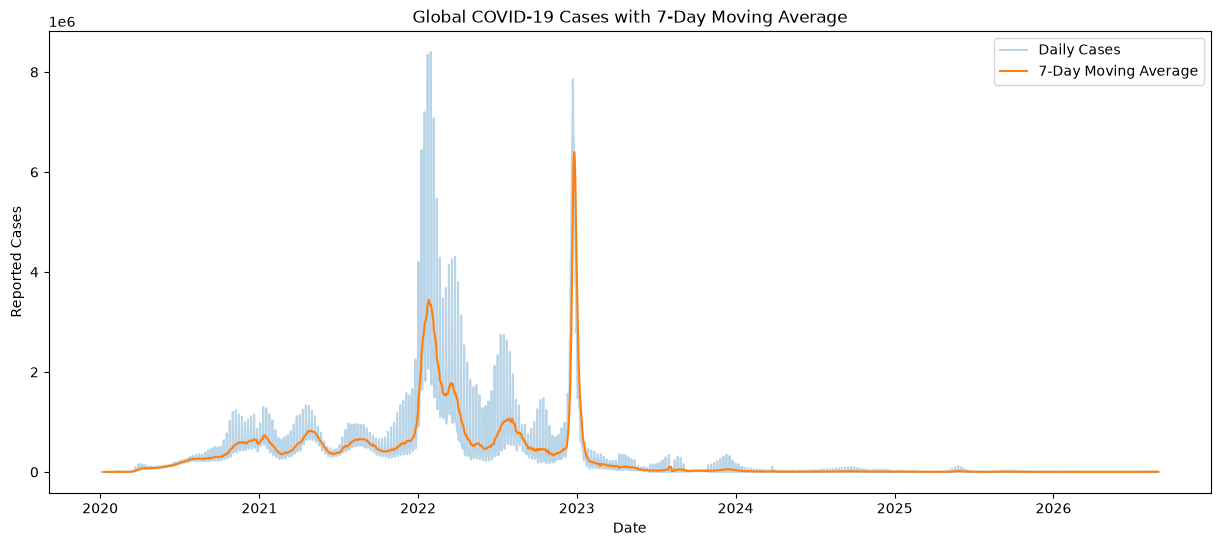

In [92]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_global["Date_reported"],
    daily_global["New_cases"],
    alpha=0.3,
    label="Daily Cases"
)

plt.plot(
    daily_global["Date_reported"],
    daily_global["Cases_7_Day_Average"],
    label="7-Day Moving Average"
)

plt.title("Global COVID-19 Cases with 7-Day Moving Average")

plt.xlabel("Date")
plt.ylabel("Reported Cases")

plt.legend()

plt.show()

In [93]:
print("=" * 50)
print("COVID-19 GLOBAL DATA ANALYSIS")
print("=" * 50)

print("Total Reported Cases:", f"{total_cases:,.0f}")
print("Total Reported Deaths:", f"{total_deaths:,.0f}")
print("Countries:", covid["Country"].nunique())
print("WHO Regions:", covid["WHO_region"].nunique())
print("Start Date:", covid["Date_reported"].min().date())
print("End Date:", covid["Date_reported"].max().date())
print("=" * 50)

COVID-19 GLOBAL DATA ANALYSIS
Total Reported Cases: 779,366,737
Total Reported Deaths: 7,116,554
Countries: 240
WHO Regions: 7
Start Date: 2020-01-04
End Date: 2026-08-30


In [94]:
final_summary = pd.DataFrame({
    "Metric": [
        "Total Reported Cases",
        "Total Reported Deaths",
        "Number of Countries",
        "Number of WHO Regions",
        "Start Date",
        "End Date"
    ],
    
    "Value": [
        total_cases,
        total_deaths,
        covid["Country"].nunique(),
        covid["WHO_region"].nunique(),
        covid["Date_reported"].min().date(),
        covid["Date_reported"].max().date()
    ]
})

final_summary

,Metric,Value
0,Total Reported Cases,779366737.0
1,Total Reported Deaths,7116554.0
2,Number of Countries,240
3,Number of WHO Regions,7
4,Start Date,2020-01-04
5,End Date,2026-08-30


#Final Analysis Questions

1. What is the total number of reported COVID-19 cases?
2. What is the total number of reported deaths?
3. Which month had the highest reported cases?
4. Which month had the highest reported deaths?
5. Which countries had the highest reported cases?
6. Which countries had the highest reported deaths?
7. Which WHO region had the highest reported cases?
8. What was the COVID-19 trend in India?
9. What is the relationship between reported cases and deaths?
10. What does the 7-day moving average show?

# Key Findings

## 1. Global Trend

The dataset shows substantial variation in reported COVID-19 cases and deaths over time, with several distinct periods of increased reporting.

## 2. Country-Level Differences

Reported COVID-19 cases and deaths vary considerably between countries.

## 3. Regional Differences

WHO regions show different patterns in reported cases and deaths.

## 4. India

India experienced substantial variation in reported COVID-19 cases over the analyzed period, with clear periods of increased reporting.

## 5. Cases and Deaths

Countries with larger reported case totals generally also have larger reported death totals, although the relationship varies between countries.

## 6. Data Limitation

COVID-19 reporting is affected by testing availability, reporting practices, retrospective corrections, case definitions, and differences between countries. Therefore, reported figures should not automatically be interpreted as exact counts of all infections or deaths.

In [95]:
region_summary = df.groupby(
    "WHO_region"
).agg(
    Total_Cases=("New_cases", "sum"),
    Total_Deaths=("New_deaths", "sum")
).reset_index()

region_summary

,WHO_region,Total_Cases,Total_Deaths
0,AFR,9590195.0,175532.0
1,AMR,193917141.0,3074523.0
2,EMR,23417911.0,351975.0
3,EUR,281769988.0,2283461.0
4,OTHER,764.0,13.0
5,SEAR,55229678.0,647305.0
6,WPR,215441060.0,583745.0


In [96]:
highest_region = region_summary.loc[
    region_summary["Total_Cases"].idxmax()
]

highest_region

WHO_region              EUR
Total_Cases     281769988.0
Total_Deaths      2283461.0
Name: 3, dtype: object

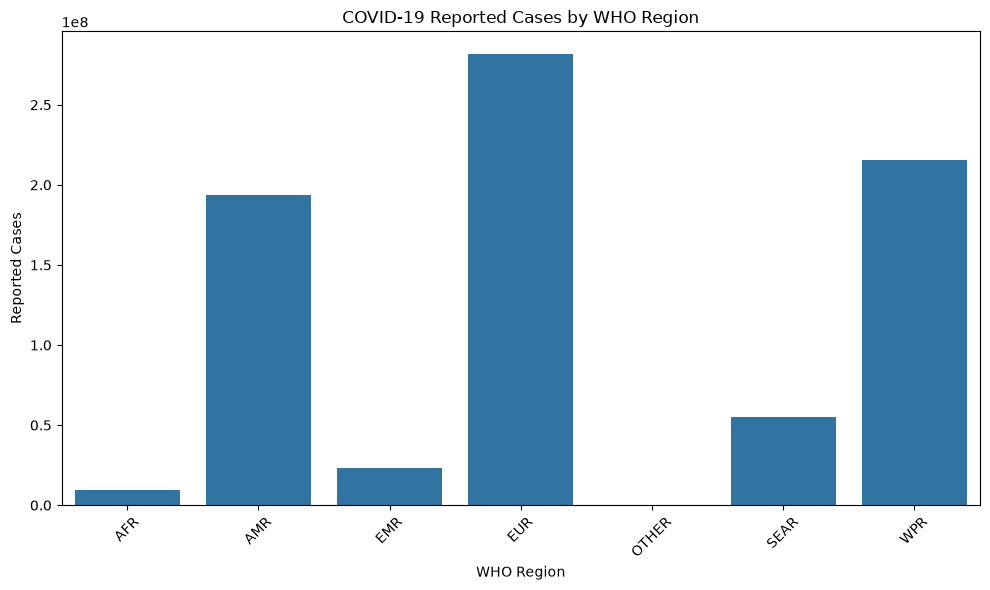

In [97]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_summary,
    x="WHO_region",
    y="Total_Cases"
)

plt.title("COVID-19 Reported Cases by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Reported Cases")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

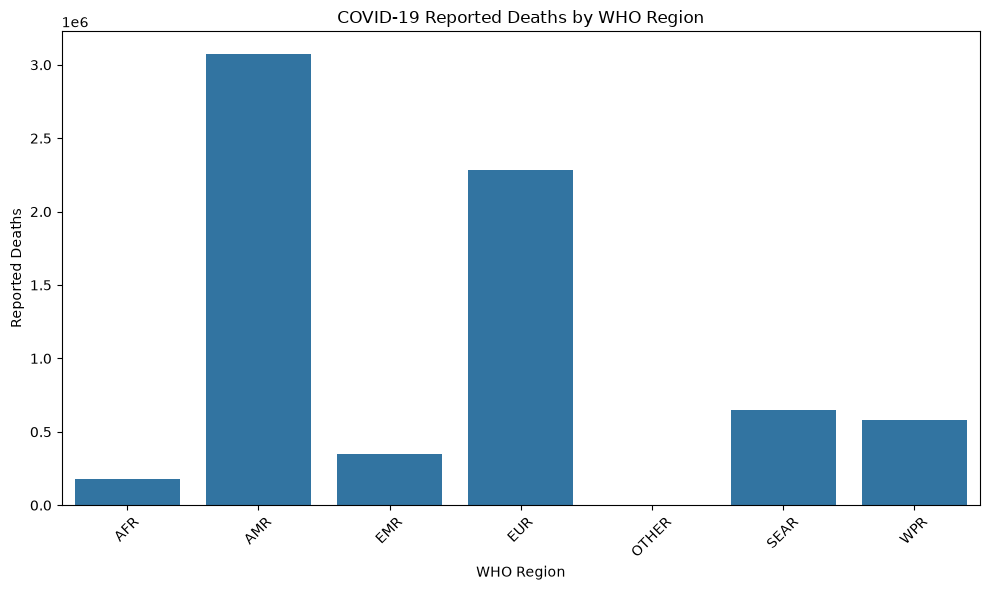

In [98]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_summary,
    x="WHO_region",
    y="Total_Deaths"
)

plt.title("COVID-19 Reported Deaths by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Reported Deaths")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 10. WHO Region Analysis

This section compares reported COVID-19 cases and deaths across WHO regions.

In [99]:
region_summary = df.groupby(
    "WHO_region"
).agg(
    Total_Cases=("New_cases", "sum"),
    Total_Deaths=("New_deaths", "sum")
).reset_index()

region_summary

,WHO_region,Total_Cases,Total_Deaths
0,AFR,9590195.0,175532.0
1,AMR,193917141.0,3074523.0
2,EMR,23417911.0,351975.0
3,EUR,281769988.0,2283461.0
4,OTHER,764.0,13.0
5,SEAR,55229678.0,647305.0
6,WPR,215441060.0,583745.0


In [100]:
highest_region = region_summary.loc[
    region_summary["Total_Cases"].idxmax()
]

highest_region

WHO_region              EUR
Total_Cases     281769988.0
Total_Deaths      2283461.0
Name: 3, dtype: object

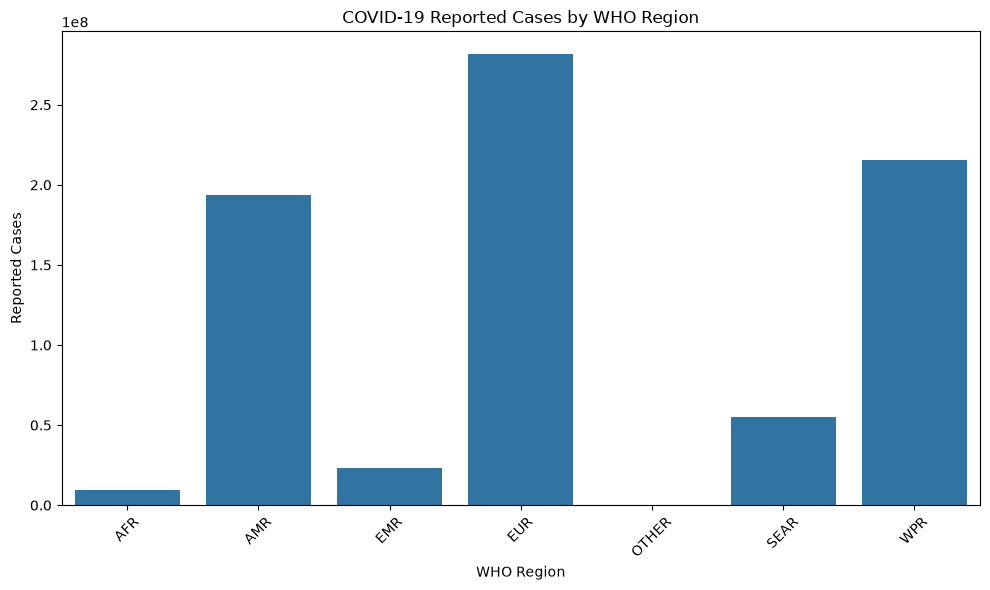

In [101]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_summary,
    x="WHO_region",
    y="Total_Cases"
)

plt.title("COVID-19 Reported Cases by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Reported Cases")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

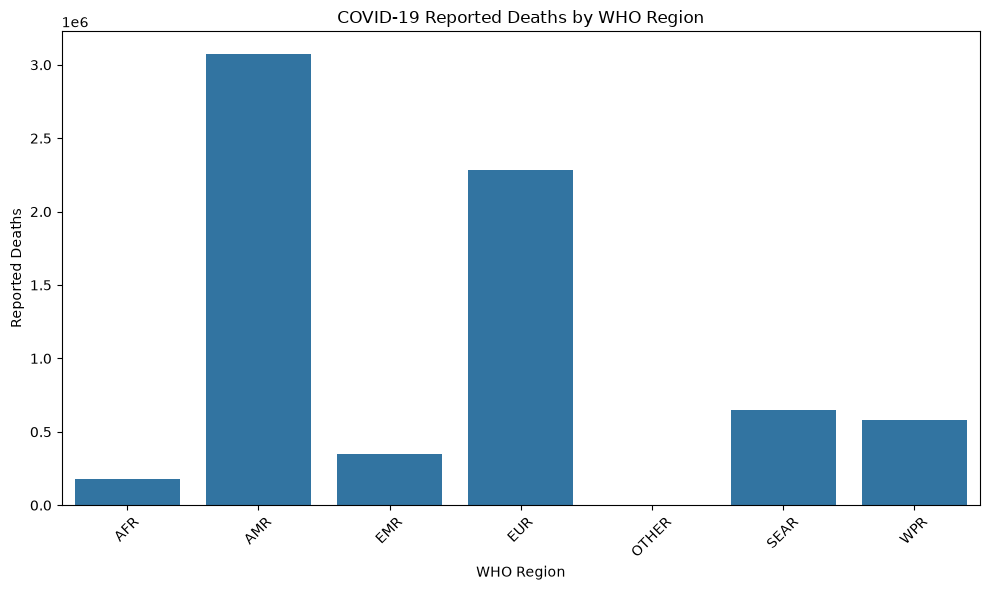

In [102]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_summary,
    x="WHO_region",
    y="Total_Deaths"
)

plt.title("COVID-19 Reported Deaths by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Reported Deaths")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### WHO Region Analysis – Observation

The WHO region analysis compares reported COVID-19 cases and deaths across different WHO regions. The results show that reported case and death totals vary substantially between regions. These differences should be interpreted in the context of differences in population size, testing, reporting practices, case definitions, and reporting frequency.

In [103]:
def compare_countries(country1, country2):
    
    selected = country_summary[
        country_summary["Country"].isin(
            [country1, country2]
        )
    ]
    
    return selected

In [104]:
compare_countries("India", "United States of America")

,Country,Total_Cases,Total_Deaths,CFR
96,India,45056221.0,533849.0,1.184851
229,United States of America,103436829.0,1239049.0,1.197880


In [105]:
def country_trend(country_name):
    
    data = covid[
        covid["Country"] == country_name
    ].copy()
    
    monthly = data.groupby(
        "Year_Month"
    )["New_cases"].sum().reset_index()
    
    monthly["Year_Month"] = (
        monthly["Year_Month"].dt.to_timestamp()
    )
    
    plt.figure(figsize=(15, 6))
    
    plt.plot(
        monthly["Year_Month"],
        monthly["New_cases"]
    )
    
    plt.title(
        f"Monthly Reported COVID-19 Cases - {country_name}"
    )
    
    plt.xlabel("Month")
    plt.ylabel("Reported Cases")
    
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

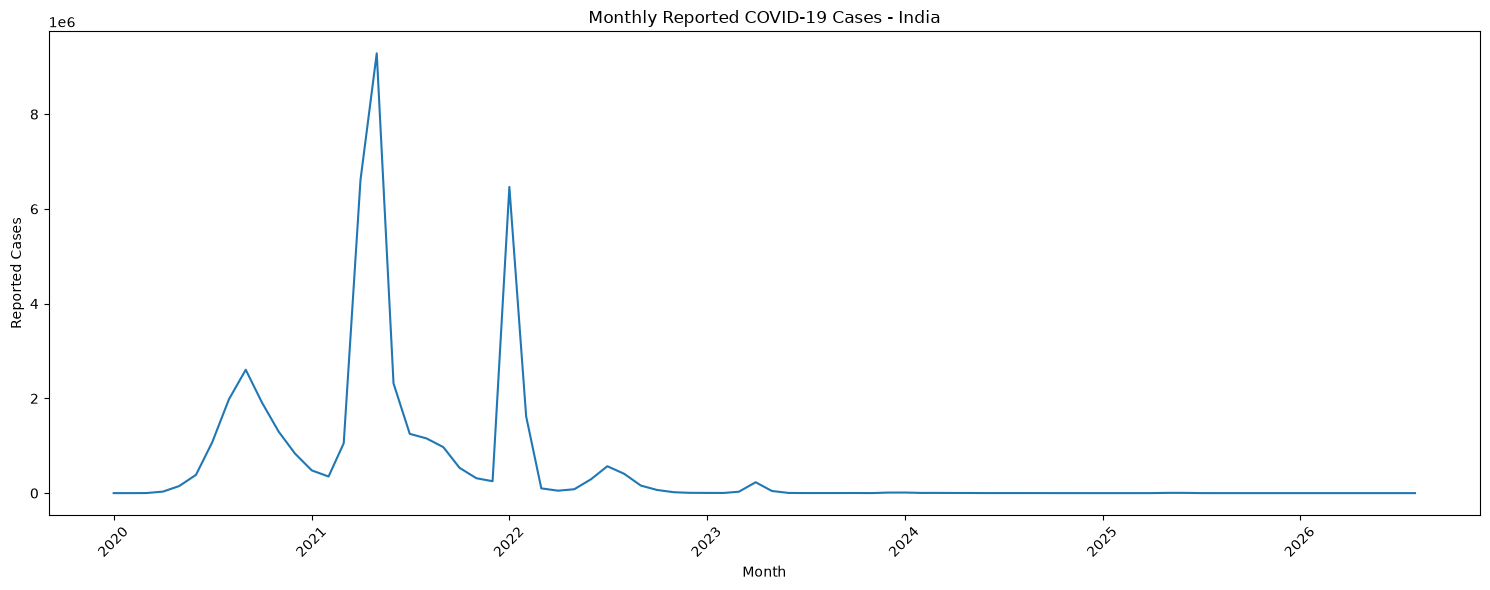

In [106]:
country_trend("India")

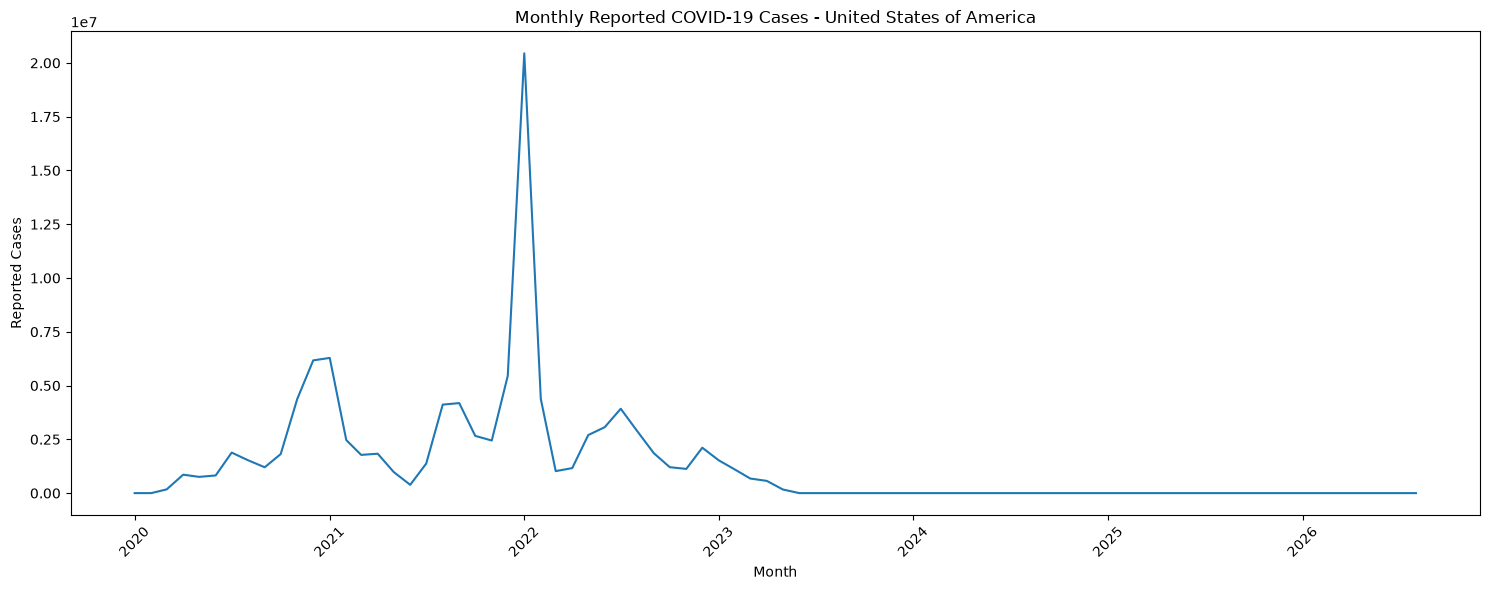

In [107]:
country_trend("United States of America")